# 第四阶段 B-1：热预算混合 MPC 教师

## 研究问题

在不放松 4.20 V、35 ℃、10 A 和每 5 s 最大变化 2 A 的条件下，能否先把教师改进为一条在 Chen2020 DFN 上比同约束过滤 1C 至少快 1% 的可行策略，再进入主动数据聚合？

这里的“通过”表示当前 Chen2020、25 ℃、10%→80% SOC 仿真域内的同约束经验验证，不表示全局最优。

## 为什么不是直接继续训练 ANN

第四阶段 A 的小型 ANN 已经很快，但它模仿的原 MPC 在 DFN 上需要 53.58 min，而过滤 1C 只需 53.33 min。教师不改善，增加数据只能让 ANN 更准确地模仿一个并不更快的目标。

本阶段先修改教师；只有下面的 1% 硬门槛通过，才允许用新教师重新标注 ANN 数据。

## 目标函数与状态触发参考

基础 MPC 代价为

\[
J_{base}=w_z\,\mathrm{mean}(z_{tar}-z)_+
+w_f(z_{tar}-z_N)_+^2
+w_{\Delta I}\,\mathrm{mean}\left(\frac{\Delta I}{I_{max}}\right)^2.
\]

新增参考为

\[
I^{ref}=\begin{cases}
8\ \mathrm{A},&z<17.67\%\ \text{且}\ T_{avg}<30.5\ ^\circ\mathrm C,\\
5\ \mathrm{A},&\text{其他情况},
\end{cases}
\]

并在预测 SOC<20% 时增加权重为 1000 的归一化参考跟踪代价。预测到达 80% 后有效电流归零，以表达“到达目标即结束”。

## 混合教师的三个模式

1. 启动参考调节器：按 0→2→4→6→8 A 平滑爬升；
2. 热预算 MPC：低 SOC 段每 5 s 重求解；
3. 终端参考调节器：20% SOC 后请求可持续 5 A，并做一步可行性检查。

模式切换由状态决定，不按固定运行时间切换。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase4b.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase4b_config import load_phase_four_b_config
from battery_fast_charge.phase4b_runner import run_phase_four_b

config = load_phase_four_b_config(PROJECT_ROOT / "configs" / "phase4b.yaml")
print(f"研究：{config.study_name}")
print("硬门槛：相对过滤1C至少缩短1%，且所有安全与求解质量检查通过")

研究：chen2020_phase4b_thermal_budget_mpc
硬门槛：相对过滤1C至少缩短1%，且所有安全与求解质量检查通过


## 运行或读取正式结果

默认读取已经生成的正式结果。将 `RUN_PHASE4B` 改为 `True` 会重新运行降阶模型和 Chen2020 DFN 闭环，通常需要数分钟。

In [2]:
RUN_PHASE4B = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4b_metrics.json"
sweep_path = PROJECT_ROOT / "data" / "phase4b" / "thermal_budget_policy_sweep.csv"
comparison_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4b_controller_comparison.csv"

if RUN_PHASE4B or any(not path.exists() for path in [metrics_path, sweep_path, comparison_path]):
    run_phase_four_b(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
sweep = pd.read_csv(sweep_path)
comparison = pd.read_csv(comparison_path)

## 诊断搜索：先确认更快的可行轨迹确实存在

,peak_current_a,switch_time_min,sustainable_current_a,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_change_a,safety_override_count,success
0,7.0,5.0,5.0,52.0833,4.14,33.5,2.0,0,True
1,8.0,3.0,5.0,52.0833,4.14,33.5,2.0,0,True
2,8.0,4.0,4.5,52.0833,4.14,33.5,2.0,0,True
3,7.0,4.0,5.0,52.1667,4.14,33.5,2.0,0,True
4,7.0,5.0,4.5,52.1667,4.14,33.5,2.0,0,True
5,8.0,4.0,5.0,52.1667,4.14,33.5,2.0,0,True
6,9.0,2.0,5.0,52.1667,4.14,33.5,2.0,0,True
7,9.0,3.0,4.5,52.1667,4.14,33.5,2.0,0,True
8,9.0,3.0,5.0,52.1667,4.14,33.5,2.0,0,True
9,7.0,3.0,5.0,52.2500,4.14,33.5,2.0,0,True


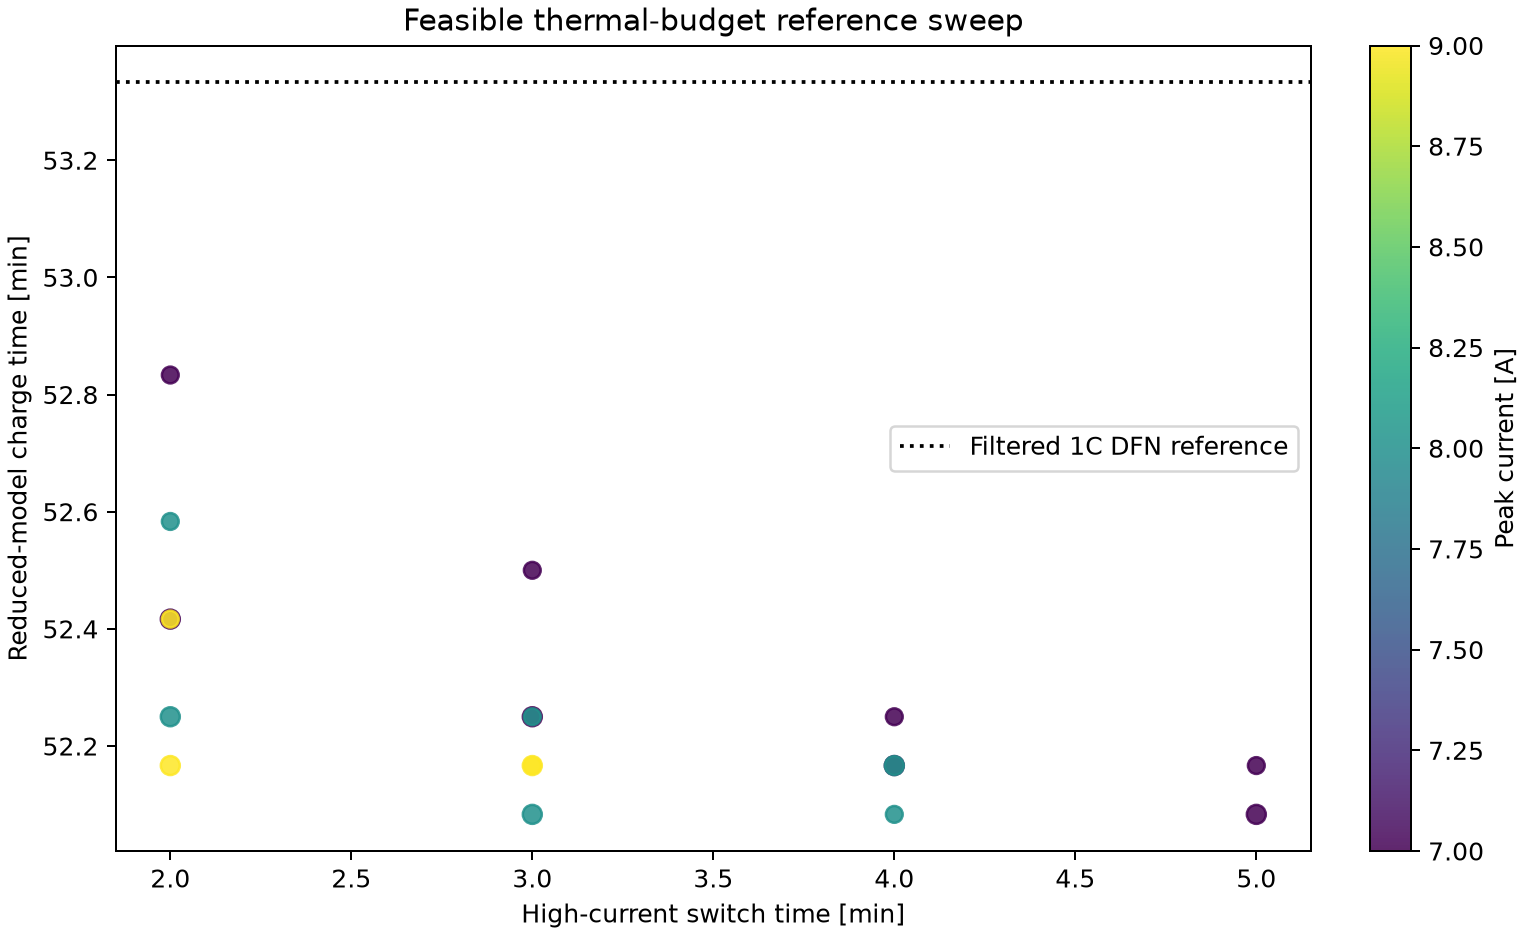

In [3]:
columns = [
    "peak_current_a", "switch_time_min", "sustainable_current_a",
    "charge_time_min", "maximum_voltage_v", "maximum_temperature_c",
    "maximum_current_change_a", "safety_override_count", "success",
]
display(sweep.loc[:, columns].head(10).round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4b_policy_sweep.png")))

窄范围搜索的作用不是证明全局最优，而是先回答一个更基本的问题：在当前模型和约束下，是否存在比 1C 更快且无需安全覆盖的轨迹。搜索给出了肯定答案，因此有理由改进教师，而不是降低验收目标。

## 同一 DFN、同一约束下的公平比较

,controller,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_a,success
0,Filtered 1C baseline,53.3333,4.1425,33.5024,5.0000,True
1,Original constrained MPC,53.5833,4.1425,33.5167,9.8326,True
2,Hybrid thermal-budget teacher,52.6667,4.1425,33.5024,8.3590,True


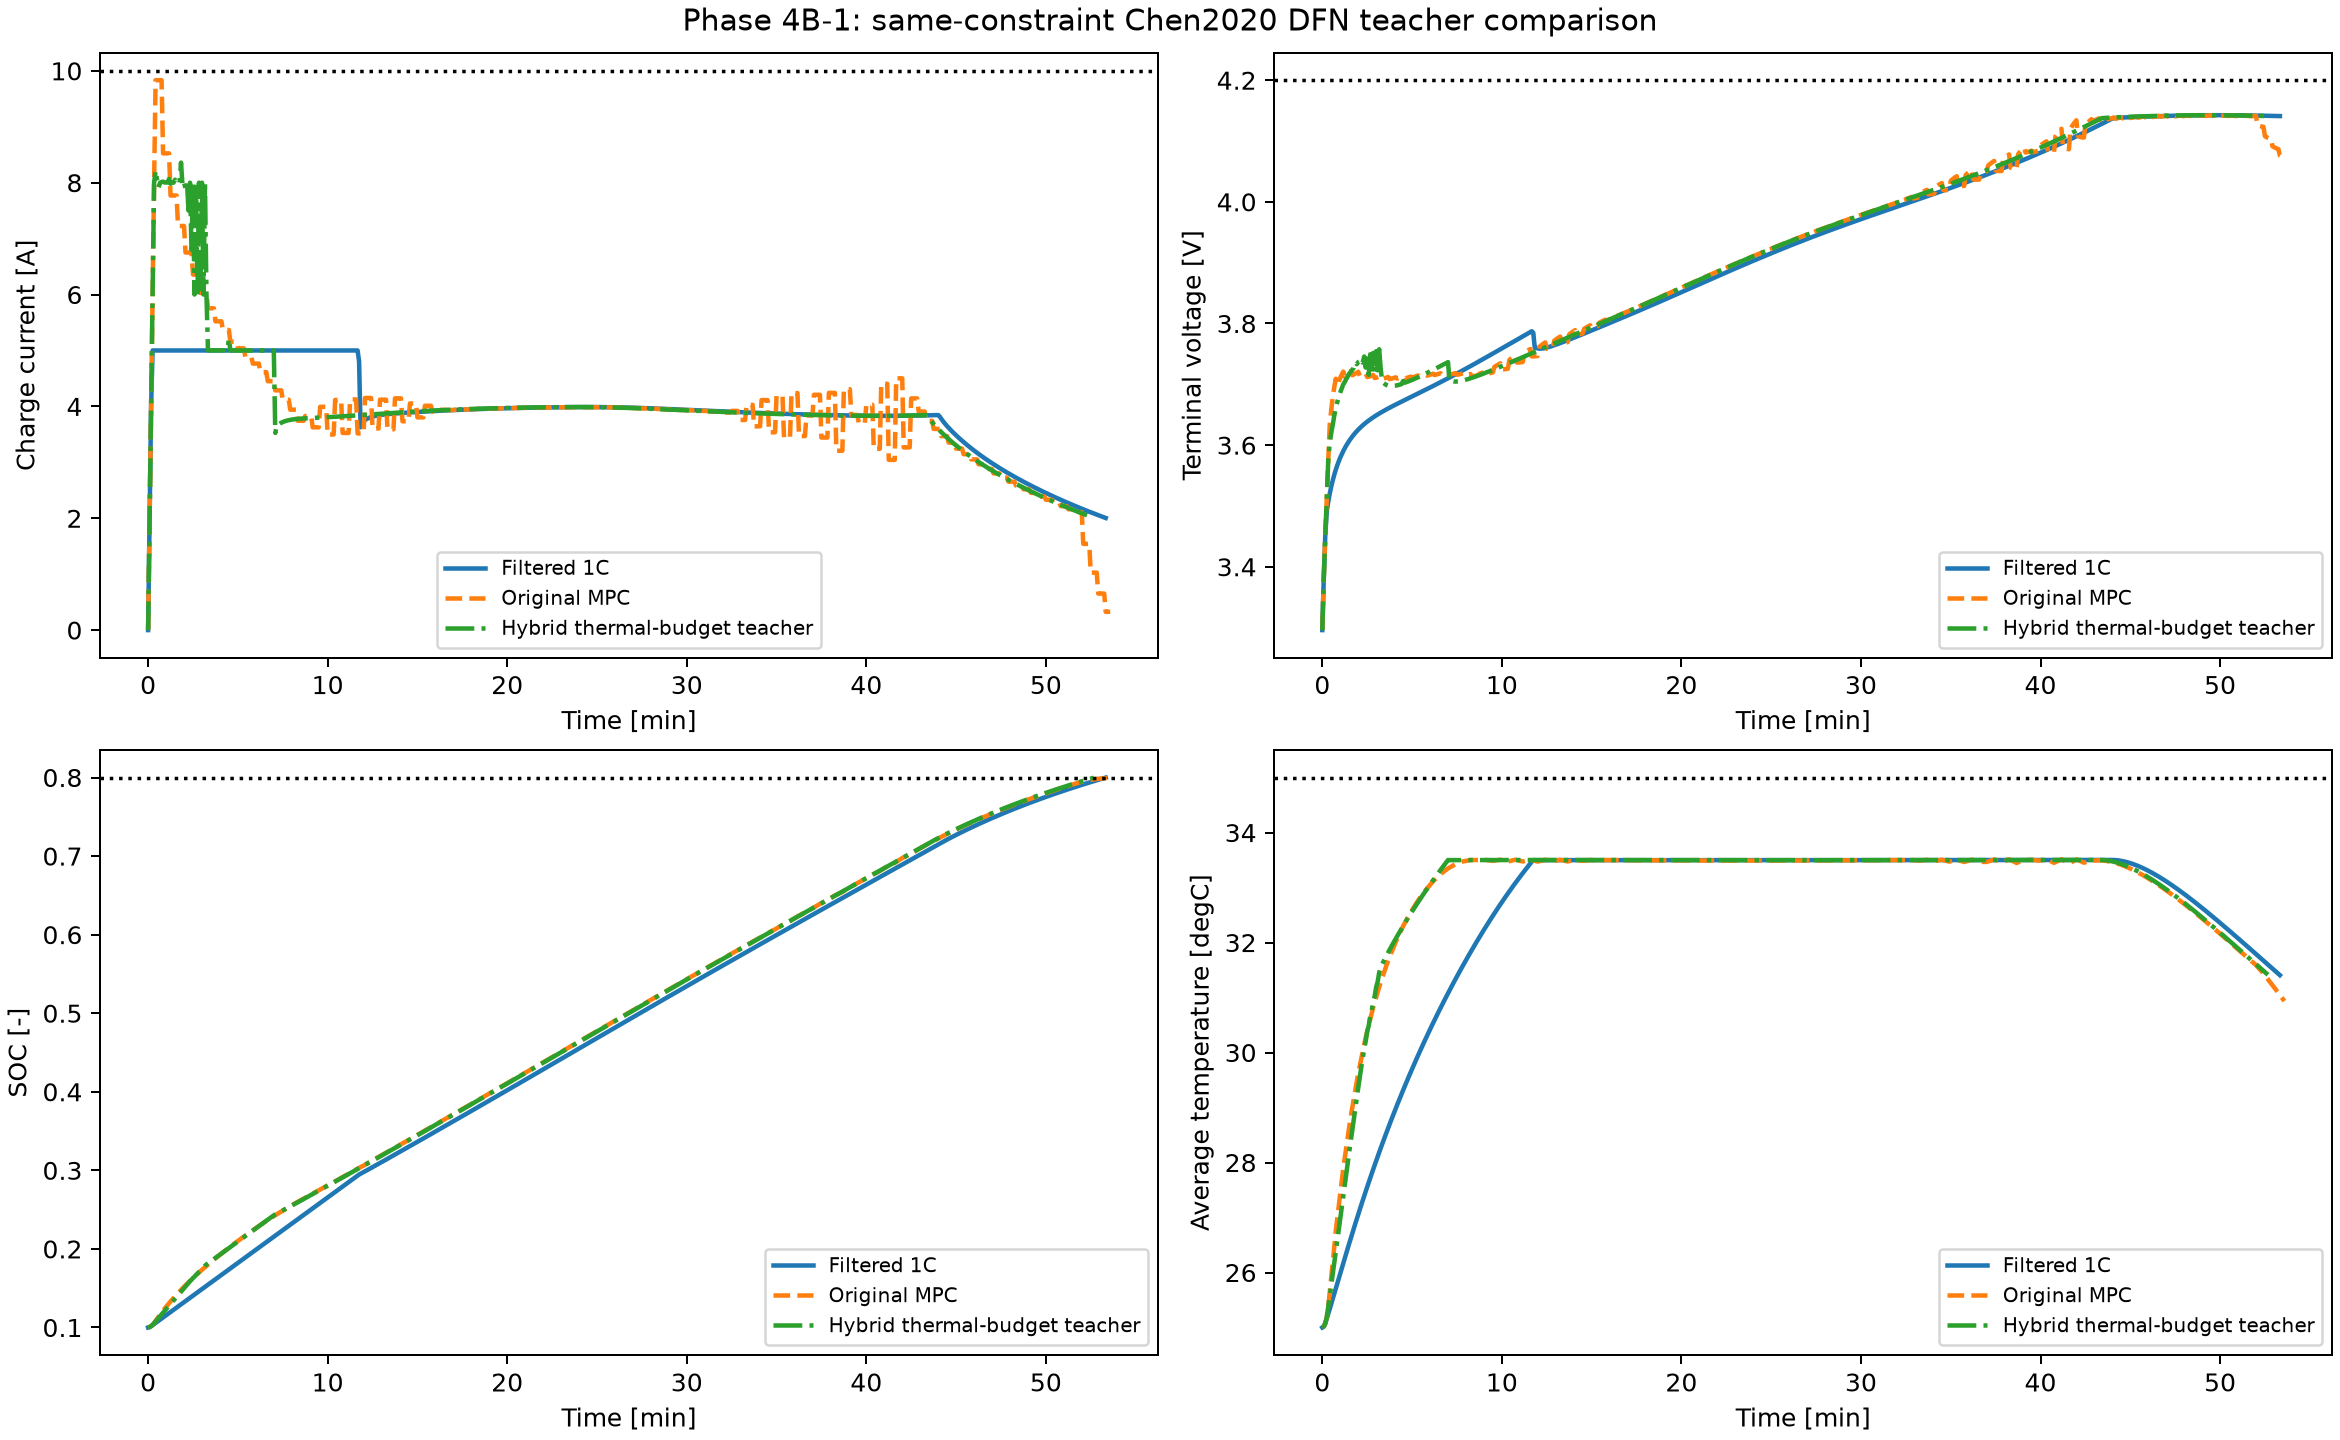

,result
charge time [min],52.6667
improvement over filtered 1C [%],1.2500
maximum voltage [V],4.1425
maximum average temperature [°C],33.5024
maximum current [A],8.3590
maximum current change [A/step],2.0000


In [4]:
display(comparison.round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4b_hybrid_teacher_comparison.png")))

dfn = metrics["hybrid_dfn_closed_loop"]
diagnostics = pd.Series({
    "charge time [min]": dfn["charge_time_min"],
    "improvement over filtered 1C [%]": 100 * metrics["improvement_fraction_over_filtered_1c"],
    "maximum voltage [V]": dfn["maximum_voltage_v"],
    "maximum average temperature [°C]": dfn["maximum_temperature_c"],
    "maximum current [A]": dfn["maximum_current_a"],
    "maximum current change [A/step]": dfn["maximum_current_change_a"],
})
display(diagnostics.to_frame("result").round(4))

混合教师用 52.67 min 到达 80% SOC，比过滤 1C 的 53.33 min 缩短 1.25%，也快于原 MPC 的 53.58 min。最高电压约 4.1425 V、最高平均温度约 33.5024 ℃，仍低于物理边界；图中的高电流只出现在早期热预算较充足的阶段。

## 求解质量与模式构成

In [5]:
quality = pd.Series({
    "startup governor steps": dfn["startup_governor_step_count"],
    "thermal-budget MPC steps": dfn["mpc_step_count"],
    "terminal governor steps": dfn["terminal_governor_step_count"],
    "optimizer success [%]": 100 * dfn["optimizer_success_fraction"],
    "prediction feasible [%]": 100 * dfn["prediction_feasible_fraction"],
    "MPC fallbacks": dfn["fallback_count"],
    "reference-governor safety overrides": dfn["reference_governor_safety_override_count"],
    "mean MPC solve time [ms]": dfn["mean_mpc_solve_time_ms"],
})
display(quality.to_frame("result").round(3))

,result
startup governor steps,15.000
thermal-budget MPC steps,39.000
terminal governor steps,578.000
optimizer success [%],97.436
prediction feasible [%],100.000
MPC fallbacks,0.000
reference-governor safety overrides,0.000
mean MPC solve time [ms],1013.455


97.44% 的优化成功率高于 95% 门槛；预测可行率 100%，且没有触发 MPC 回退。注意，整个教师不是“全程 MPC”：大部分中后段由已验证的一步参考调节器执行。因此下一阶段生成标签时必须保存控制模式。

## 验收与下一阶段准入

In [6]:
display(pd.Series(metrics["checks"], name="passed").to_frame())
display(pd.Series({
    "Phase 4B-1 passed": metrics["success"],
    "Ready for active data aggregation": metrics["ready_for_active_data_aggregation"],
    "Globally optimal controller proven": False,
    "Ready for a real BMS": False,
}, name="result").to_frame())

,passed
reduced_closed_loop,True
dfn_closed_loop,True
minimum_time_improvement,True
zero_mpc_fallbacks,True
zero_reference_governor_safety_overrides,True


,result
Phase 4B-1 passed,True
Ready for active data aggregation,True
Globally optimal controller proven,False
Ready for a real BMS,False


## 结论与边界

- 4B-1 的硬门槛全部通过，可以开始主动数据聚合；
- 下一步应让新教师重新标注 ANN 闭环访问到的状态，并重新进行整轨迹训练/验证/测试划分；
- 当前结论仅适用于 Chen2020、25 ℃、10%→80% SOC 和现有约束；
- 集总平均温度不能排除极耳或局部热点，真实 BMS 接入前仍需要多温度、参数扰动、老化和硬件验证。